In [1]:
import numpy as np

def runup_stockdon(H0, T, beta):
    """Compute R2% runup via Stockdon et al. (2006)."""
    g = 9.81
    L0 = g * T**2 / (2.0 * np.pi)
    term1 = 0.35 * beta * np.sqrt(H0 * L0)
    term2 = np.sqrt(H0 * L0 * (0.563 * beta**2 + 0.004))
    return 1.1 * (term1 + term2)

cases = [
    ("North (with reef)",    0.0017, 1.25, 3.25),
    ("North (no reef)",      0.0017, 1.70, 3.65),
    ("West (with reef)",     0.0005, 1.50, 3.55),
    ("West (no reef)",       0.0005, 1.68, 3.60),
    ("East (with reef)",     0.0011, 0.90, 3.50),
    ("East (no reef)",       0.0011, 1.30, 3.50),
]

for label, slope, Hs, Tp in cases:
    R2 = runup_stockdon(Hs, Tp, slope)
    print(f"{label}: {R2:.2f} m")


North (with reef): 0.32 m
North (no reef): 0.42 m
West (with reef): 0.38 m
West (no reef): 0.41 m
East (with reef): 0.29 m
East (no reef): 0.35 m


In [2]:
import numpy as np

def runup_stockdon(H0, T, beta):
    """Compute R2% runup via Stockdon et al. (2006)."""
    g = 9.81
    L0 = g * T**2 / (2.0 * np.pi)
    
    # Iribarren number (surf similarity parameter)
    xi = beta / np.sqrt(H0 / L0)
    
    if xi >= 0.3:
        # Intermediate/reflective beach (Eq. 19 in Stockdon 2006)
        setup = 0.35 * beta * np.sqrt(H0 * L0)
        swash = np.sqrt(H0 * L0 * (0.563 * beta**2 + 0.004)) / 2  # ✅ divide by 2
        R2 = 1.1 * (setup + swash)
    else:
        # Dissipative beach (Eq. 18 in Stockdon 2006)
        R2 = 0.043 * np.sqrt(H0 * L0)
    
    return R2, xi

cases = [
    ("North (with reef)",  0.0017, 1.14, 3.6),
    ("North (no reef)",    0.0017, 1, 3.67),
    ("West (with reef)",   0.0005, 1.41, 3.56),
    ("West (no reef)",     0.0005, 1.59, 3.55),
    ("East (with reef)",   0.0011, 0.35, 3.32),
    ("East (no reef)",     0.0011, 0.48, 3.28),
]

print(f"{'Case':<25} {'xi':>6} {'Regime':<15} {'R2 (m)':>8}")
print("-" * 58)
for label, slope, Hs, Tp in cases:
    R2, xi = runup_stockdon(Hs, Tp, slope)
    regime = "Reflective" if xi >= 0.3 else "Dissipative"
    print(f"{label:<25} {xi:>6.4f} {regime:<15} {R2:>8.3f}")

Case                          xi Regime            R2 (m)
----------------------------------------------------------
North (with reef)         0.0072 Dissipative        0.207
North (no reef)           0.0076 Dissipative        0.201
West (with reef)          0.0019 Dissipative        0.227
West (no reef)            0.0018 Dissipative        0.241
East (with reef)          0.0077 Dissipative        0.106
East (no reef)            0.0065 Dissipative        0.122


In [3]:
import numpy as np

def runup_stockdon(H0, T, beta):
    """Compute R2% runup via Stockdon et al. (2006)."""
    g = 9.81
    L0 = g * T**2 / (2.0 * np.pi)
    
    # Iribarren number (surf similarity parameter)
    xi = beta / np.sqrt(H0 / L0)
    
    if xi >= 0.3:
        # Intermediate/reflective beach (Eq. 19 in Stockdon 2006)
        setup = 0.35 * beta * np.sqrt(H0 * L0)
        swash = np.sqrt(H0 * L0 * (0.563 * beta**2 + 0.004)) / 2  # ✅ divide by 2
        R2 = 1.1 * (setup + swash)
    else:
        # Dissipative beach (Eq. 18 in Stockdon 2006)
        R2 = 0.043 * np.sqrt(H0 * L0)
    
    return R2, xi

cases = [
    ("North (with reef)",  0.0017, 1.17, 3.6),
    ("North (no reef)",    0.0017, 1.46, 3.67),
    ("West (with reef)",   0.0005, 1.42, 3.56),
    ("West (no reef)",     0.0005, 1.64, 3.55),
    ("East (with reef)",   0.0011, 0.72, 3.32),
    ("East (no reef)",     0.0011, 0.99, 3.28),
]

print(f"{'Case':<25} {'xi':>6} {'Regime':<15} {'R2 (m)':>8}")
print("-" * 58)
for label, slope, Hs, Tp in cases:
    R2, xi = runup_stockdon(Hs, Tp, slope)
    regime = "Reflective" if xi >= 0.3 else "Dissipative"
    print(f"{label:<25} {xi:>6.4f} {regime:<15} {R2:>8.3f}")

Case                          xi Regime            R2 (m)
----------------------------------------------------------
North (with reef)         0.0071 Dissipative        0.209
North (no reef)           0.0065 Dissipative        0.238
West (with reef)          0.0019 Dissipative        0.228
West (no reef)            0.0017 Dissipative        0.244
East (with reef)          0.0054 Dissipative        0.151
East (no reef)            0.0045 Dissipative        0.175


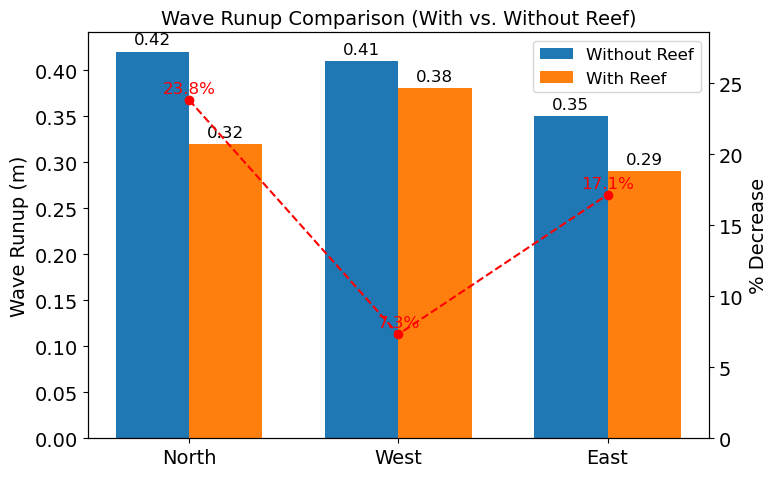

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Data
locations = ["North", "West", "East"]
runup_without_reef = [0.42, 0.41, 0.35]
runup_with_reef    = [0.32, 0.38, 0.29]
percent_decrease   = [23.80952381, 7.317073171, 17.14285714]

x = np.arange(len(locations))  # the label locations
width = 0.35                   # the width of the bars
# Increase all default font sizes
plt.rcParams.update({
    'font.size': 14,         # base font size for text
    'axes.titlesize': 14,    # title
    'axes.labelsize': 14,    # x/y labels
    'xtick.labelsize': 14,   # x tick labels
    'ytick.labelsize': 14,   # y tick labels
    'legend.fontsize': 12    # legend
})
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot the "without reef" and "with reef" bar groups
rects1 = ax1.bar(x - width/2, runup_without_reef, width, label='Without Reef')
rects2 = ax1.bar(x + width/2, runup_with_reef, width, label='With Reef')

# Primary y-axis settings (wave runup)
ax1.set_ylabel('Wave Runup (m)')
ax1.set_xticks(x)
ax1.set_xticklabels(locations)
ax1.set_title('Wave Runup Comparison (With vs. Without Reef)')
ax1.legend()

# Secondary y-axis for % decrease
ax2 = ax1.twinx()
ax2.plot(x, percent_decrease, color='red', marker='o', linestyle='--', label='% Decrease')
ax2.set_ylabel('% Decrease')
ax2.set_ylim(0, max(percent_decrease)*1.2)  # some padding above max

# Optionally add data labels for bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax1.annotate(f"{height:.2f}",
                 xy=(rect.get_x() + rect.get_width()/2, height),
                 xytext=(0, 3),  # offset in points
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=12)

# Optionally add data labels for the % decrease line
for i, val in enumerate(percent_decrease):
    ax2.annotate(f"{val:.1f}%",
                 xy=(i, val),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', color='red', fontsize=12)

fig.tight_layout()
plt.show()


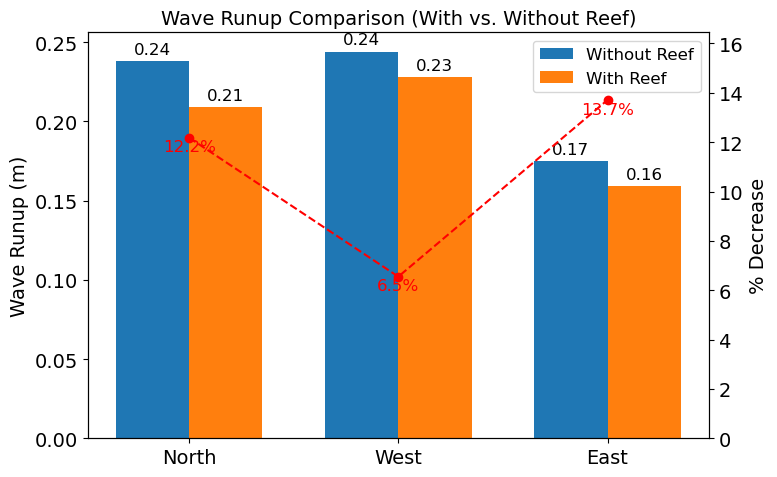

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Data
locations = ["North", "West", "East"]
runup_without_reef = [0.238, 0.244, 0.175]
runup_with_reef    = [0.209, 0.228, 0.159]
percent_decrease   = [12.18, 6.55, 13.71]

x = np.arange(len(locations))  # the label locations
width = 0.35                   # the width of the bars
# Increase all default font sizes
plt.rcParams.update({
    'font.size': 14,         # base font size for text
    'axes.titlesize': 14,    # title
    'axes.labelsize': 14,    # x/y labels
    'xtick.labelsize': 14,   # x tick labels
    'ytick.labelsize': 14,   # y tick labels
    'legend.fontsize': 12    # legend
})
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot the "without reef" and "with reef" bar groups
rects1 = ax1.bar(x - width/2, runup_without_reef, width, label='Without Reef')
rects2 = ax1.bar(x + width/2, runup_with_reef, width, label='With Reef')

# Primary y-axis settings (wave runup)
ax1.set_ylabel('Wave Runup (m)')
ax1.set_xticks(x)
ax1.set_xticklabels(locations)
ax1.set_title('Wave Runup Comparison (With vs. Without Reef)')
ax1.legend()

# Secondary y-axis for % decrease
ax2 = ax1.twinx()
ax2.plot(x, percent_decrease, color='red', marker='o', linestyle='--', label='% Decrease')
ax2.set_ylabel('% Decrease')
ax2.set_ylim(0, max(percent_decrease)*1.2)  # some padding above max

# Optionally add data labels for bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax1.annotate(f"{height:.2f}",
                 xy=(rect.get_x() + rect.get_width()/2, height),
                 xytext=(0, 3),  # offset in points
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=12)

# Optionally add data labels for the % decrease line
for i, val in enumerate(percent_decrease):
    ax2.annotate(f"{val:.1f}%",
                 xy=(i, val),
                 xytext=(0, -12),
                 textcoords="offset points",
                 ha='center', va='bottom', color='red', fontsize=12)

fig.tight_layout()
plt.show()
